# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

# 📦 Import Required Libraries

**Why we use this:** Before building any model we need the core deep learning framework and the text preprocessing utilities. TensorFlow gives us the layers to build RNN, LSTM and GRU models, and the Keras preprocessing tools convert raw text into a numeric format the model can learn from.

In [1]:
# TensorFlow is the core deep learning framework used to build and train the RNN, LSTM and GRU models
import tensorflow as tf
# Tokenizer converts raw text into integer tokens based on word frequency
from tensorflow.keras.preprocessing.text import Tokenizer
# pad_sequences makes all input sequences equal in length by adding padding
from tensorflow.keras.preprocessing.sequence import pad_sequences
# Sequential lets us stack layers one after another to build each model
from tensorflow.keras import Sequential
# Embedding, SimpleRNN, LSTM, GRU and Dense are the layers used across the three models
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## Part A: Baseline Implementation (Original Specification)

This part covers the missing piece from the checklist: a training curve over the full **100 epochs**, using the default sample corpus and default settings (embedding 32, hidden units 64). The custom corpus, larger embedding/hidden size, 200-epoch training, and 10-word generation already exist further below in Part B and are not repeated here.

# 📥 Load Text Corpus (Baseline)
This is the default sample corpus used only for the 100-epoch baseline run below.

In [2]:
corpus_base = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus_base)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation (Baseline)

**What this does:** Same encoding and n-gram process used in Part B, applied here to the default corpus so the baseline models have their own independent data.

In [3]:
tokenizer_base = Tokenizer()
tokenizer_base.fit_on_texts([corpus_base])

total_words_base = len(tokenizer_base.word_index) + 1
print("Vocabulary size:", total_words_base)

input_sequences_base = []
for line in corpus_base.split('\n'):
    token_list = tokenizer_base.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences_base.append(n_gram_seq)

max_len_base = max(len(seq) for seq in input_sequences_base)
input_sequences_base = pad_sequences(input_sequences_base, maxlen=max_len_base, padding='pre')

X_base = input_sequences_base[:, :-1]
y_base = input_sequences_base[:, -1]

print("X shape:", X_base.shape)
print("y shape:", y_base.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN — Baseline (100 Epochs)
Default embedding size (32) and hidden units (64), trained for 100 epochs.

In [4]:
rnn_model_base = Sequential([
    Embedding(total_words_base, 32, input_length=max_len_base-1),
    SimpleRNN(64),
    Dense(total_words_base, activation='softmax')
])

rnn_model_base.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history_base = rnn_model_base.fit(X_base, y_base, epochs=100, verbose=1)
print("Vanilla RNN baseline training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.0286 - loss: 3.6162
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0571 - loss: 3.5819
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1143 - loss: 3.5568
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1429 - loss: 3.5357
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1429 - loss: 3.5150
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1714 - loss: 3.4934
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2000 - loss: 3.4720
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1714 - loss: 3.4480
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1714 - loss: 3.4244
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1714 - loss: 3.4040
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1714 - loss: 3.3786
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1714 - lo

# 🔒 Model 2: LSTM — Baseline (100 Epochs)
Same default settings as the RNN above, only the layer type changes.

In [5]:
lstm_model_base = Sequential([
    Embedding(total_words_base, 32, input_length=max_len_base-1),
    LSTM(64),
    Dense(total_words_base, activation='softmax')
])

lstm_model_base.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history_base = lstm_model_base.fit(X_base, y_base, epochs=100, verbose=1)
print("LSTM baseline training completed")

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.0286 - loss: 3.6108
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0857 - loss: 3.6062
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.0571 - loss: 3.6027
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0571 - loss: 3.5993
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0571 - loss: 3.5958
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0571 - loss: 3.5923
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0571 - loss: 3.5885
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0571 - loss: 3.5845
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0571 - loss: 3.5801
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0571 - loss: 3.5753
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0571 - loss: 3.5698
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0571 - lo

# ⚡ Model 3: GRU — Baseline (100 Epochs)
Same default settings as the RNN and LSTM above.

In [6]:
gru_model_base = Sequential([
    Embedding(total_words_base, 32, input_length=max_len_base-1),
    GRU(64),
    Dense(total_words_base, activation='softmax')
])

gru_model_base.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history_base = gru_model_base.fit(X_base, y_base, epochs=100, verbose=1)
print("GRU baseline training completed")

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.0286 - loss: 3.6091
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0857 - loss: 3.6029
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1143 - loss: 3.5984
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1429 - loss: 3.5942
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1429 - loss: 3.5900
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1714 - loss: 3.5862
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1714 - loss: 3.5822
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2000 - loss: 3.5782
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2000 - loss: 3.5736
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1714 - loss: 3.5693
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1714 - loss: 3.5645
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1714 - lo

## 📉 Compare Training Loss — Baseline (100 Epochs)

**Why we plot this:** This is the cross-entropy loss curve for all three models across the full 100 epochs of baseline training.

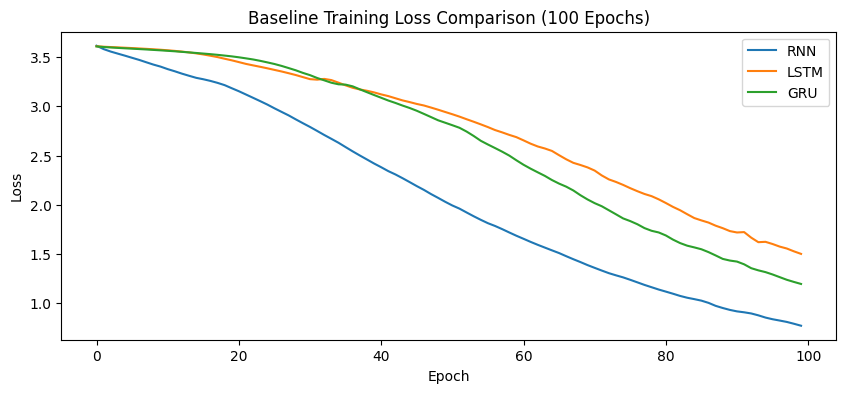

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history_base.history['loss'], label='RNN')
plt.plot(lstm_history_base.history['loss'], label='LSTM')
plt.plot(gru_history_base.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Training Loss Comparison (100 Epochs)")
plt.legend()
plt.show()

## Part B: Student Customization Tasks (Enhanced Version)

Everything below this point already covers the 5 beginner customization tasks (custom corpus, larger embedding/hidden size, 200 epochs, 10-word generation) plus EDA, model summaries, accuracy comparison and the final comparison table, and is unchanged from before.

# 📥 Load Text Corpus
We use a **small custom paragraph corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

**Why a multi-line paragraph:** A single sentence does not give the model enough variety in word order, so a short paragraph is used here, this way the n-gram sequences created later have more patterns to learn from.

In [8]:
# Multi-line paragraph used as the training corpus
corpus = '''
deep learning is transforming artificial intelligence rapidly
recurrent neural networks are useful for sequential data processing
lstm helps remember long term dependencies in a sentence
gru is faster and simpler than lstm but performs similarly
text generation models predict the next word in a sequence
attention mechanisms further improve context understanding in deep learning
neural networks learn useful patterns from large amounts of training data
deep learning models can generate meaningful and coherent sentences
'''
print(corpus)


deep learning is transforming artificial intelligence rapidly
recurrent neural networks are useful for sequential data processing
lstm helps remember long term dependencies in a sentence
gru is faster and simpler than lstm but performs similarly
text generation models predict the next word in a sequence
attention mechanisms further improve context understanding in deep learning
neural networks learn useful patterns from large amounts of training data
deep learning models can generate meaningful and coherent sentences



# 🔍 Exploratory Data Analysis (EDA)

**Why we do this:** Before turning text into numbers, it is useful to actually look at the data, how many lines and words it has, which words repeat the most, and how long an average line is. This gives a sense of how much real pattern the model has to learn from, and helps explain the results we see later.

In [9]:
# Break the corpus into clean lines and individual words for analysis
lines = [line.strip() for line in corpus.strip().split('\n') if line.strip()]
all_words = corpus.split()

word_freq = Counter(all_words)

print("Total lines in corpus:", len(lines))
print("Total words in corpus:", len(all_words))
print("Total unique words:", len(word_freq))
print("Average words per line:", round(len(all_words) / len(lines), 2))
print("Most common words:", word_freq.most_common(10))

Total lines in corpus: 8
Total words in corpus: 74
Total unique words: 59
Average words per line: 9.25
Most common words: [('deep', 3), ('learning', 3), ('in', 3), ('is', 2), ('neural', 2), ('networks', 2), ('useful', 2), ('data', 2), ('lstm', 2), ('a', 2)]


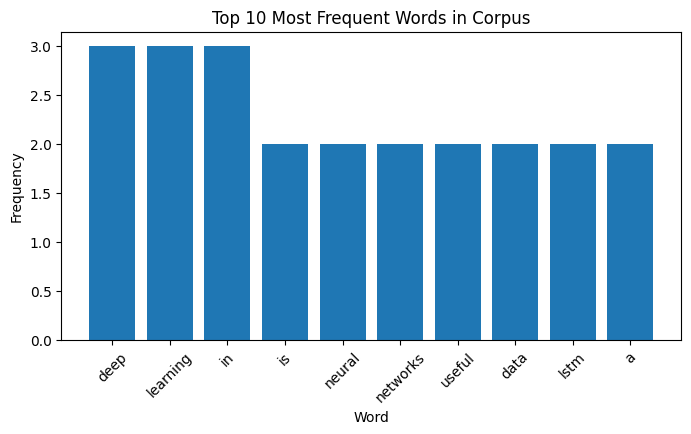

In [10]:
# Visualizing word frequency gives a quick sense of which words the model will see most often
common_words = word_freq.most_common(10)
words, counts = zip(*common_words)

plt.figure(figsize=(8,4))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Top 10 Most Frequent Words in Corpus")
plt.show()

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

**What this does:** A neural network cannot work with raw words, so each word is first mapped to a unique integer, this step is called encoding. Then every line is broken into progressive n-gram sequences, for example "deep learning is" becomes the pairs (deep → learning) and (deep learning → is), so the model learns to predict the next word at every position in a sentence, not only at the end.

In [11]:
# Tokenizer learns the vocabulary from the corpus and assigns a unique integer to every word
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)
# Looking at a few word-to-index pairs shows what the encoding actually looks like
print("Sample word-to-index mapping:", list(tokenizer.word_index.items())[:10])

# Each line is broken into progressive n-gram sequences
input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

print("Total training sequences generated:", len(input_sequences))
print("Example sequence before padding:", input_sequences[0])

# Sequences are padded with zeros at the start (pre-padding) so every sample has the same length
max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

print("Example sequence after padding:", input_sequences[0])

# X holds the input words and y holds the target word to be predicted
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 60
Sample word-to-index mapping: [('deep', 1), ('learning', 2), ('in', 3), ('is', 4), ('neural', 5), ('networks', 6), ('useful', 7), ('data', 8), ('lstm', 9), ('a', 10)]
Total training sequences generated: 66
Example sequence before padding: [1, 2]
Example sequence after padding: [0 0 0 0 0 0 0 0 0 1 2]
X shape: (66, 10)
y shape: (66,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

**How it works:** A Simple RNN reads a sequence one word at a time and carries a hidden state forward to the next step. The same weights are reused at every step, so during training the gradient is multiplied repeatedly, over a long sequence this gradient tends to shrink toward zero, this is the vanishing gradient problem, and it makes the network forget information from many steps back.

**Layer settings:** The Embedding layer turns each word index into a 64-dimensional vector. SimpleRNN(128) gives the network 128 hidden units to carry information forward. The final Dense layer with softmax outputs a probability for every word in the vocabulary, and the word with the highest probability is taken as the prediction.

In [12]:
# Vanilla RNN baseline model
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

# Printing the summary shows the layer shapes and parameter count of the model
rnn_model.summary()

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

# verbose=1 prints the loss and accuracy after every epoch, so the training process is visible
rnn_history = rnn_model.fit(X, y, epochs=200, verbose=1)
print("Vanilla RNN training completed")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.0000e+00 - loss: 4.0926
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0909 - loss: 3.9963
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1061 - loss: 3.9310
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0909 - loss: 3.8754
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0758 - loss: 3.8170
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0758 - loss: 3.7652
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1515 - loss: 3.7083
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1970 - loss: 3.6481
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1818 - loss: 3.5881
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1970 - loss: 3.5276
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2121 - loss: 3.4647
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2121 

# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

**How it works:** Along with the hidden state, an LSTM cell keeps a separate memory cell. Three gates decide what happens to this memory at every step, the forget gate decides what old information to drop, the input gate decides what new information to add, and the output gate decides what part of the memory to expose to the next step. This gating mechanism is what allows an LSTM to carry information over much longer sequences than a Simple RNN.

**Layer settings:** Same embedding size (64) and same hidden unit count (128) as the RNN are used here, so any difference in results comes from the architecture, not from unequal settings.

In [13]:
# LSTM model with gated memory cells
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.summary()

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=1)
print("LSTM training completed")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.0455 - loss: 4.0945
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0758 - loss: 4.0848
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1667 - loss: 4.0781
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1061 - loss: 4.0706
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0758 - loss: 4.0622
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0606 - loss: 4.0519
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0606 - loss: 4.0375
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0455 - loss: 4.0175
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0606 - loss: 3.9893
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0455 - loss: 3.9525
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0455 - loss: 3.9132
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0606 - lo

# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

**How it works:** GRU simplifies the LSTM cell, it merges the forget and input gates into a single update gate, and adds a reset gate that controls how much of the past hidden state to forget when computing a new candidate state. With fewer gates and no separate memory cell, GRU has fewer parameters than LSTM, which usually makes it train faster while still handling long-term dependencies reasonably well.

**Layer settings:** Same embedding size (64) and hidden units (128) as the other two models are kept, again for a fair comparison.

In [14]:
# GRU model with reset and update gates
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.summary()

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=1)
print("GRU training completed")

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.0152 - loss: 4.0969
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0909 - loss: 4.0819
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1515 - loss: 4.0722
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2121 - loss: 4.0625
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2121 - loss: 4.0531
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2727 - loss: 4.0432
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2727 - loss: 4.0327
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2273 - loss: 4.0202
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2121 - loss: 4.0058
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2121 - loss: 3.9893
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1970 - loss: 3.9698
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1970 - lo

## 📉 Compare Training Loss

**Why we plot this:** Plotting the loss curves of all three models on the same graph lets us visually compare how fast each architecture's training loss drops and stabilizes over 200 epochs.

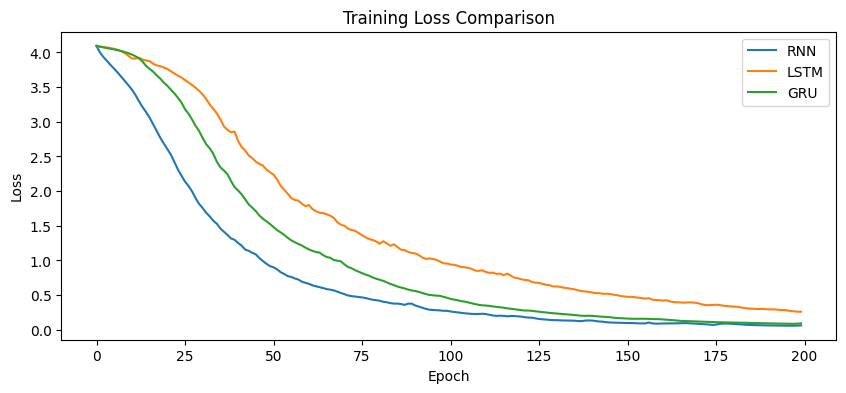

In [15]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

## 📈 Compare Training Accuracy

**Why we plot this too:** Loss only tells us how wrong the predictions are on average, accuracy tells us how often the model predicts the exact correct next word. Looking at both together gives a fuller picture of how each architecture is actually learning.

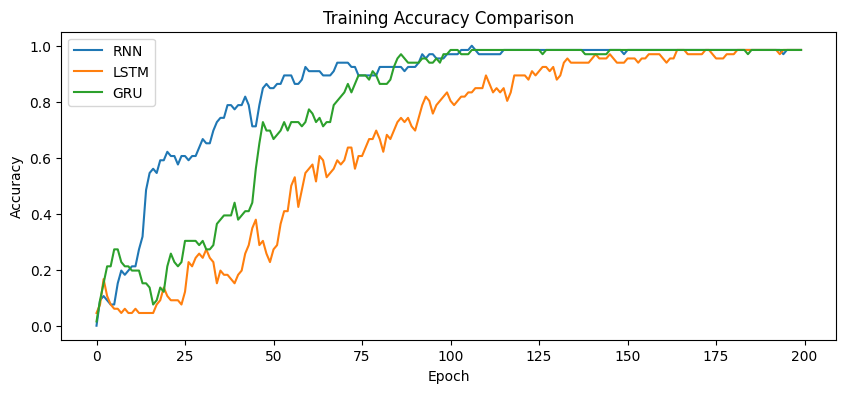

In [16]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['accuracy'], label='RNN')
plt.plot(lstm_history.history['accuracy'], label='LSTM')
plt.plot(gru_history.history['accuracy'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.show()

## 📊 Model Comparison Summary

**Why we build this table:** A single table with the final loss, final accuracy and total parameter count of all three models makes it easy to see the trade-off between model size and performance at a glance, instead of reading numbers off three separate plots.

In [17]:
comparison_df = pd.DataFrame({
    "Model": ["Vanilla RNN", "LSTM", "GRU"],
    "Final Training Loss": [
        rnn_history.history['loss'][-1],
        lstm_history.history['loss'][-1],
        gru_history.history['loss'][-1]
    ],
    "Final Training Accuracy": [
        rnn_history.history['accuracy'][-1],
        lstm_history.history['accuracy'][-1],
        gru_history.history['accuracy'][-1]
    ],
    "Total Parameters": [
        rnn_model.count_params(),
        lstm_model.count_params(),
        gru_model.count_params()
    ]
})

comparison_df

,Model,Final Training Loss,Final Training Accuracy,Total Parameters
0,Vanilla RNN,0.062818,0.984848,36284
1,LSTM,0.259878,0.984848,110396
2,GRU,0.091283,0.984848,86076


# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

**What it does:** At every step, the model looks at the seed text so far, predicts a probability for every word in the vocabulary, and picks the single most likely next word using `np.argmax`. The chosen word is appended back to the seed text, and the process repeats for the required number of words.

In [18]:
def generate_text(model, seed_text, next_words=10):
    # Loop runs once for every new word that needs to be generated
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        # np.argmax picks the index of the word with the highest predicted probability
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [19]:
# Generate 10 words of continuation from each model, using the same seed text for a fair comparison
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning models can generate meaningful and coherent sentences similarly data than
LSTM: deep learning is transforming artificial intelligence rapidly rapidly but performs performs similarly
GRU : deep learning models can generate meaningful and coherent sentences sentences sentences sentences


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory, because of the vanishing gradient problem over longer sequences
- **LSTM** captures long-range grammar dependencies better, since its gates let it choose what to remember and what to forget
- **GRU** gives similar performance with fewer gates and fewer parameters, which usually means faster training
- The comparison table and accuracy plot above show this trade-off directly, in terms of both parameter count and learning speed
- This notebook helps students understand **sequence modeling mathematically and practically**